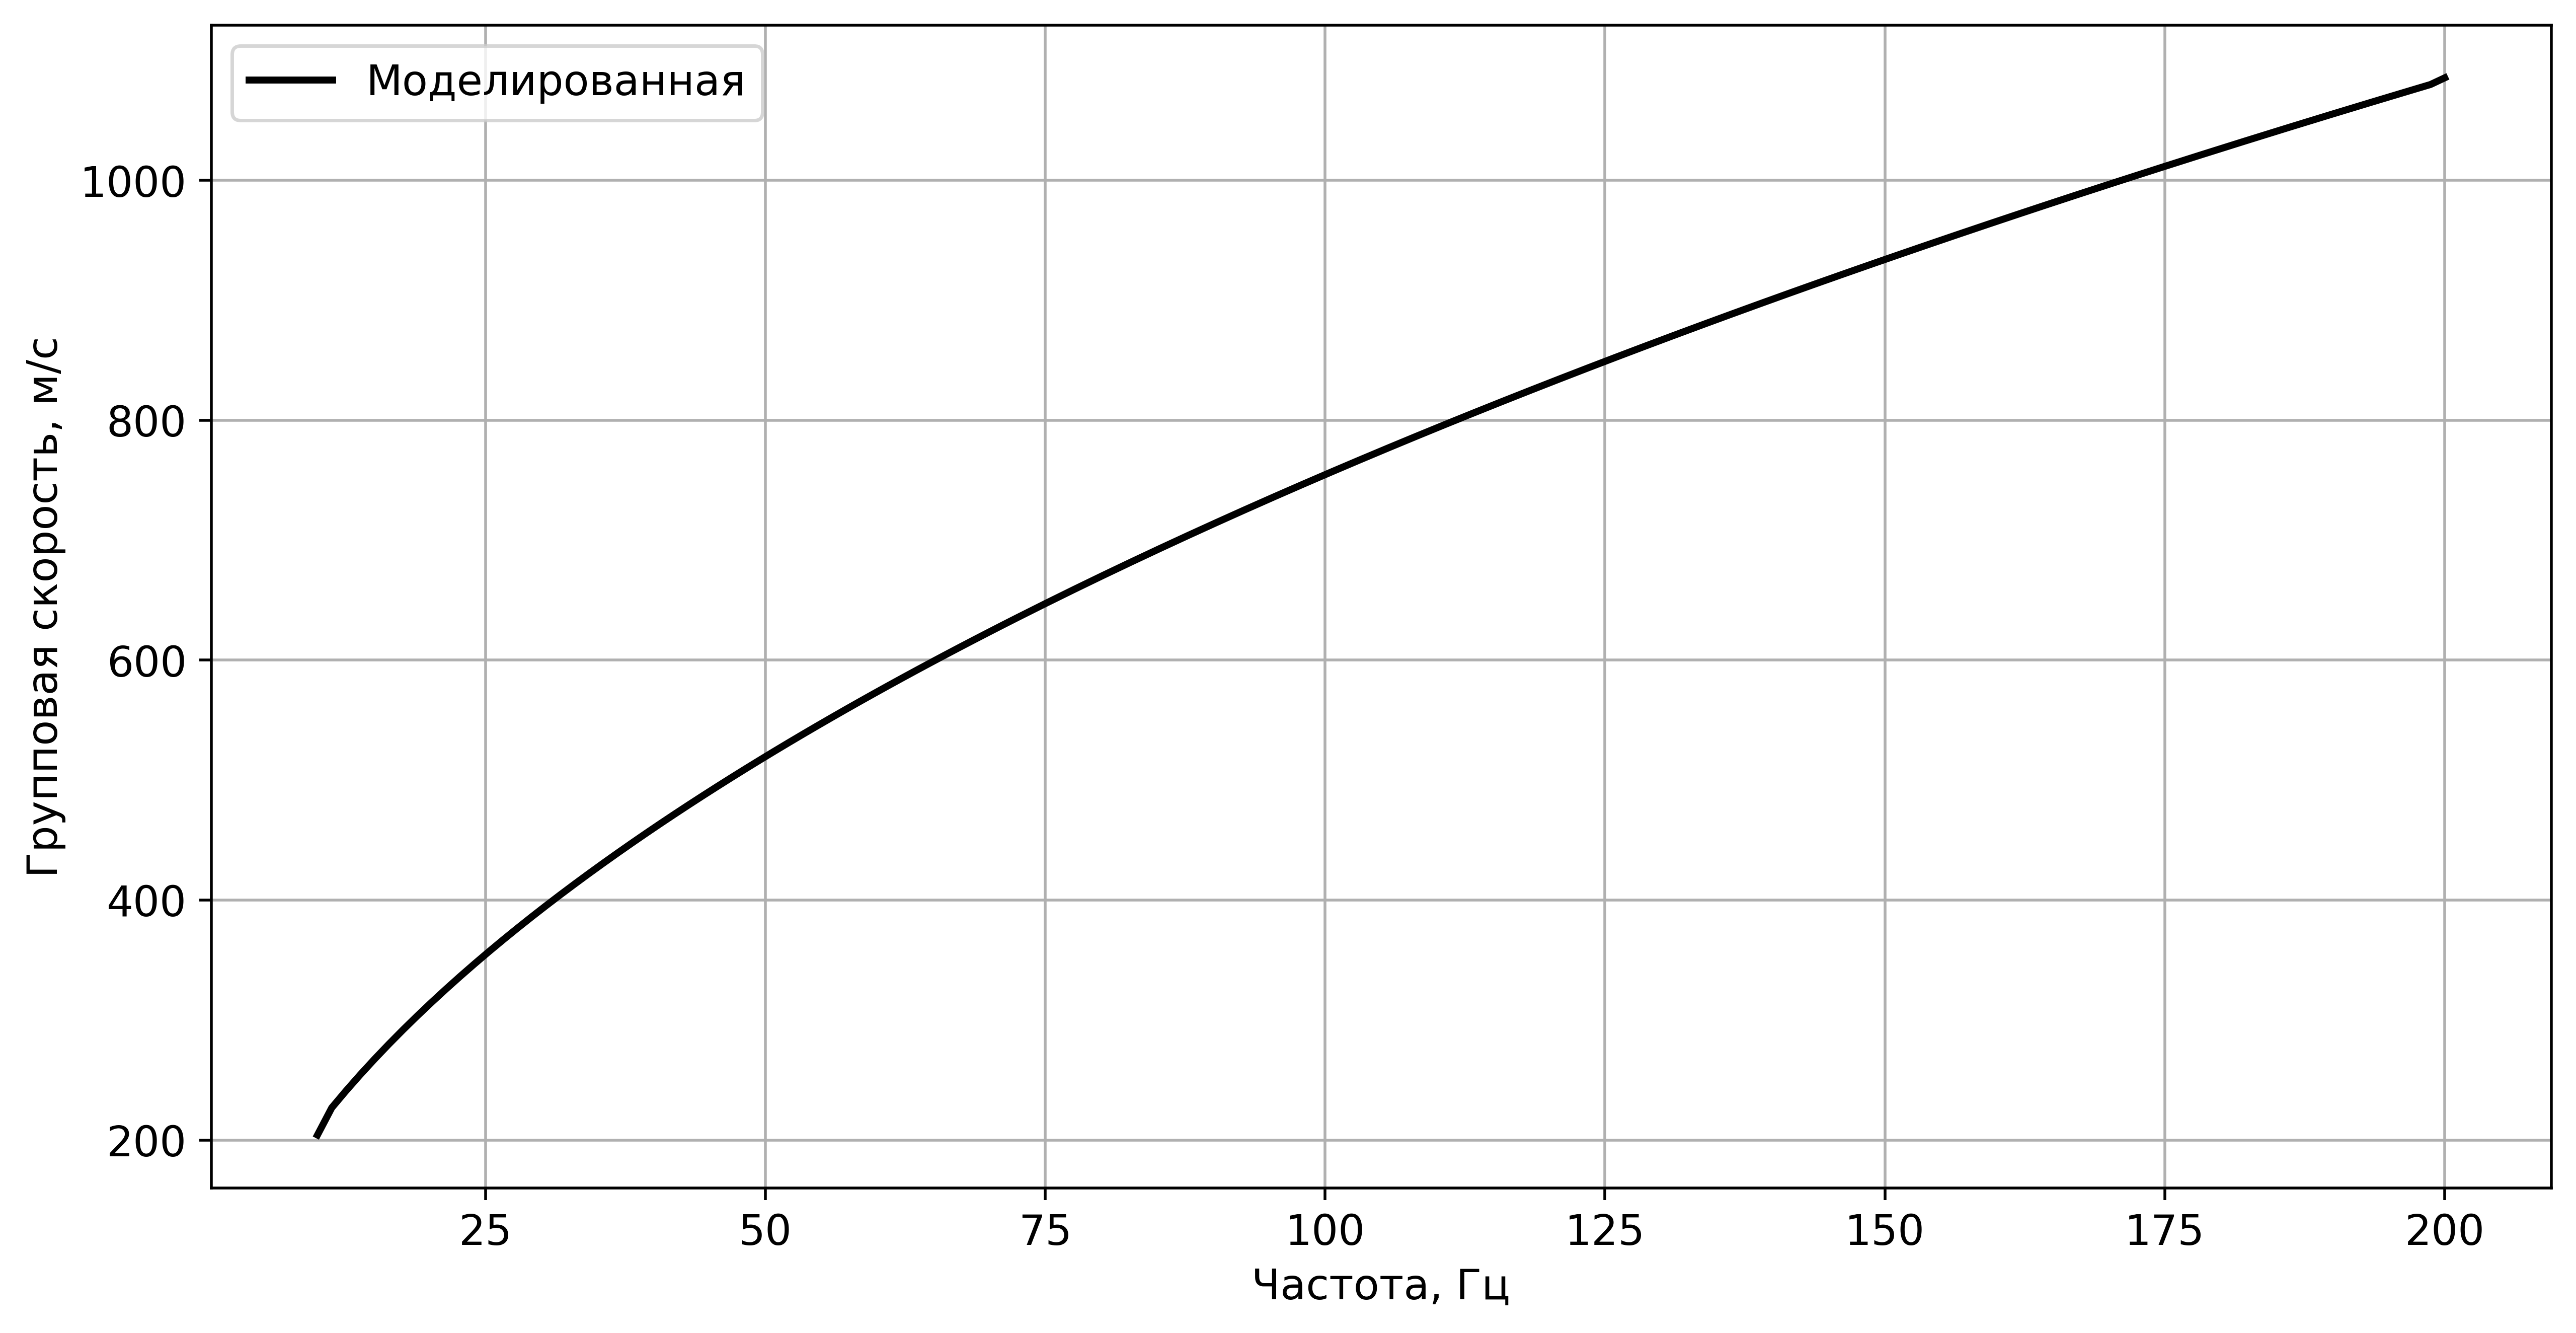

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import brentq

plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

def ph_to_gr(c_ph, f):
    """Вычисление групповой скорости через логарифмическую производную"""
    dc_df = np.gradient(c_ph, f)
    c_gr = c_ph / (1 - (f / c_ph) * dc_df)
    return c_gr

def dispStein_scalar(c, f, h, rho, logE, mu, rho_w, V, g):
    """Скалярное уравнение Стейна для ОДНОЙ частоты"""
    E = 10**logE
    D = E * h**3 / (12 * (1 - mu**2))
    
    omega = 2 * np.pi * f
    k = omega / c
    
    radicand = k**2 - (omega/V)**2
    if radicand <= 0:
        return -1e10
        
    term1 = k**4
    term2 = (rho * h * omega**2) / D
    term3 = (rho_w / D) * (omega**2 / np.sqrt(radicand) - g)
    
    return term1 - term2 - term3

def compute_group_velocity_fast(freq, h, rho, logE, mu, rho_w, V, g):
    c_ph = np.zeros_like(freq)
    for i, f in enumerate(freq):
        try:
            c_ph[i] = brentq(dispStein_scalar, 10.0, V - 0.01, 
                             args=(f, h, rho, logE, mu, rho_w, V, g))
        except ValueError:
            return None
            
    return ph_to_gr(c_ph, freq)


h_true, rho_true, E_true, mu_true = 0.39, 925.0, 5.0e9, 0.33
logE_true = np.log10(E_true)
rho_w, V, g = 1023.0, 1440.0, 9.8
consts = (rho_w, V, g)

freq_obs = np.linspace(10, 200, 150)
c_gr_true = compute_group_velocity_fast(freq_obs, h_true, rho_true, logE_true, mu_true, *consts)

np.random.seed(42)
noise_std = 4.0
c_gr_exp = c_gr_true + np.random.normal(0, noise_std, size=len(c_gr_true))

plt.figure(figsize=(12, 6), dpi=500)
plt.plot(freq_obs, c_gr_true, 'k-', lw=2, label='Моделированная')
# plt.scatter(freq_obs, c_gr_exp, c='crimson', s=15, alpha=0.7, label='Эксперимент (с шумом)')
plt.xlabel('Частота, Гц')
plt.ylabel('Групповая скорость, м/с')
plt.legend()
plt.grid(True)
plt.show()